# LLM Image-Similarity Experiment

Separate from `manual_chatgpt_loop.ipynb` and independent of `image_view_matcher.py`'s CLIP embeddings.

**Goal:** test whether the LLM itself (via its own vision, not CLIP) can pick the top-3 most visually similar reference views when given:
- the current screenshot,
- all 18 reference images, each labeled with only its **view name** (e.g. `[Dorsal]`) — **no text description** of what each view means, and
- a request to rank the top-3 most similar reference images, purely from looking at the pictures.

This sends all 19 images (1 current + 18 reference) in a single API call via `ask_chatgpt(..., extra_images=[(label, path), ...])` — a new optional parameter added to the existing `chatgpt_client.ask_chatgpt()`, backward compatible with everything else that calls it.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))

from IPython.display import Image, display
from camera_reasoning.chatgpt_client import ask_chatgpt
from camera_reasoning.view_description_generator import _extract_json_object  # reuse existing JSON-extraction logic

## Load reference view labels + image paths

From `reference_views_metadata.json` only — deliberately NOT `view_descriptions.json`, since this experiment is about testing the LLM's raw visual judgment, not text-assisted judgment.

In [2]:
metadata = json.load(open("../reference_views/reference_views_metadata.json"))
extra_images = [(m["view_name"], "../" + m["image_path"]) for m in metadata]
print(f"{len(extra_images)} reference images loaded: {[label for label, _ in extra_images]}")

18 reference images loaded: ['Dorsal', 'Plantar', 'Medial', 'Lateral', 'Distal', 'Proximal', 'DorsalMedial', 'DorsalLateral', 'DorsalDistal', 'DorsalProximal', 'PlantarMedial', 'PlantarLateral', 'PlantarDistal', 'PlantarProximal', 'MedialDistal', 'MedialProximal', 'LateralDistal', 'LateralProximal']


## Pick the current image

Point this at any screenshot you want to test — e.g. the latest render, or any `output/screenshots/step_*.png`.

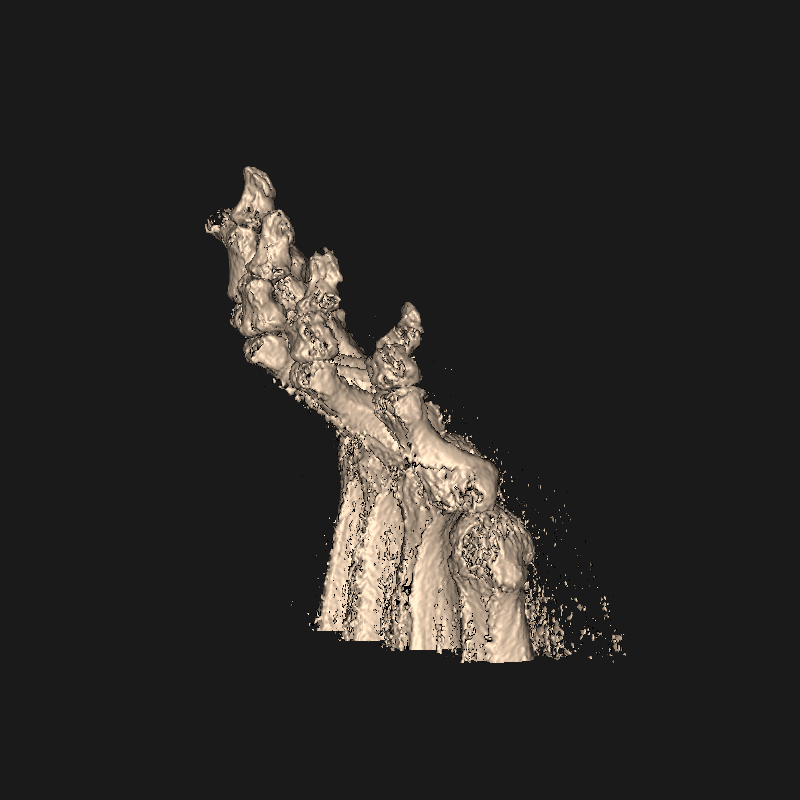

In [3]:
current_image_path = "../output/screenshots/latest.png"
display(Image(current_image_path))

## Ask the LLM to rank the top-3 most similar reference images

In [4]:
PROMPT = """You are comparing a CURRENT rendered image of foot bones against a set of labeled
reference images of the same object, taken from different camera views.

You will see:
  1. The CURRENT image first.
  2. Then several labeled REFERENCE images, each preceded by its label in square
     brackets (e.g. \"[Dorsal]\") immediately followed by that image.

You are given ONLY the labels — no text description of what each view means. Judge
purely from the images themselves.

Task: identify the top 3 reference images that are most visually similar to the
CURRENT image, ranked from most to least similar.

Return only valid JSON with this schema:
{
  \"top_3\": [
    {\"rank\": 1, \"view_label\": \"...\", \"reasoning\": \"...\"},
    {\"rank\": 2, \"view_label\": \"...\", \"reasoning\": \"...\"},
    {\"rank\": 3, \"view_label\": \"...\", \"reasoning\": \"...\"}
  ]
}

Rules:
- view_label must be exactly one of the provided reference labels.
- Return JSON only, no extra text.
"""

response = ask_chatgpt(
    prompt=PROMPT,
    screenshot_path=current_image_path,
    extra_images=extra_images,
)
print(response)

```json
{
  "top_3": [
    {
      "rank": 1,
      "view_label": "Distal",
      "reasoning": "The CURRENT image shows an oblique dorsolateral view with toes pointing upward and to the left, with the broader tarsal/metatarsal base visible at bottom right. The Distal reference image shows a nearly identical perspective with the same diagonal orientation, toe positioning, and structural arrangement of the metatarsals and phalanges."
    },
    {
      "rank": 2,
      "view_label": "DorsalLateral",
      "reasoning": "This view shows a dorsolateral perspective that closely matches the CURRENT image's angle and orientation. The positioning of the metatarsals, the visible lateral side of the foot, and the toe arrangement extending diagonally upward are very similar, though the camera angle is slightly different."
    },
    {
      "rank": 3,
      "view_label": "LateralDistal",
      "reasoning": "This reference shows a lateral view with distal emphasis, capturing similar anatomical feat

## Parse the result

In [ ]:
parsed = _extract_json_object(response)
if parsed and "top_3" in parsed:
    for entry in parsed["top_3"]:
        print(f"{entry['rank']}. {entry['view_label']}")
        print(f"   {entry['reasoning']}\n")
else:
    print("Could not parse a top_3 JSON block from the response above.")

## (Optional) Compare against the CLIP image-embedding top-3

Same current image, same reference bank — but via `image_view_matcher.py`'s CLIP embeddings instead of the LLM's own vision. Useful to see whether the LLM's judgment agrees with the embedding-based ranking.

In [ ]:
from camera_reasoning.image_view_matcher import ImageViewMatcher

image_matcher = ImageViewMatcher(reference_dir="../reference_views", cache_path="../reference_embeddings.pkl")
image_matcher.build_index()
clip_result = image_matcher.match(current_image_path, top_k=3)

print("CLIP embedding top-3:")
for m in clip_result["top_matches"]:
    print(f"  {m['rank']}. {m['view_label']:<20s} similarity={m['similarity']:.4f}")